# **Airline Passenger Forecasting using LSTM Neural Networks (Time-Series Demand Forecasting System)**

### **Project Objective**

The objective of this project is to develop a **Time-Series Forecasting System** using **Long Short-Term Memory (LSTM) Neural Networks** to predict future airline passenger traffic based on historical data.

Accurate demand forecasting is critical for airlines and transportation systems to optimize capacity, pricing, and operations. This project focuses on leveraging deep learning techniques to model temporal patterns and trends in passenger data.

The system is designed to:

- Predict **future airline passenger volumes**  
- Capture **temporal dependencies in time-series data**  
- Learn **seasonality and trends in passenger traffic**  
- Demonstrate the effectiveness of **LSTM networks for forecasting tasks**  

This project is highly applicable in:
- airline demand forecasting  
- revenue management  
- capacity planning  
- transportation analytics  

### **Dataset Used**

This project utilizes time-series datasets containing historical airline passenger data.

### **Dataset Sources**

- **Airline Passenger Dataset** *(commonly used dataset for time-series forecasting)*  

### **Dataset Characteristics**

The dataset includes:

- **Time index**:
  - monthly timestamps  

- **Target variable**:
  - number of airline passengers  

Key characteristics:
- univariate time-series data  
- seasonal patterns  
- trend components  

### **How Dataset is Used in the Project**

The dataset is processed through a time-series forecasting pipeline:

- **Data preprocessing**
  - normalization / scaling  
  - handling time index  

- **Sequence generation**
  - converting time-series into input-output sequences  

- **Train-test split**
  - temporal split to preserve sequence integrity  

- **Model training**
  - LSTM learns sequential dependencies  
  - predicts future values  

The dataset enables the model to learn **temporal patterns and trends**, which are essential for forecasting.




### **Import Libraries:**

In [1]:
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

import warnings
warnings.filterwarnings("ignore")

import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

print("Libraries imported successfully.")


Libraries imported successfully.


### **Load Dataset:**

In [2]:
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv"
df = pd.read_csv(url)
df.head()


,Month,Passengers
0,1949-01,112
1,1949-02,118
2,1949-03,132
3,1949-04,129
4,1949-05,121


### **Inspect Dataset:**

In [3]:
print("Shape:", df.shape)
print(df.info())


Shape: (144, 2)
<class 'pandas.DataFrame'>
RangeIndex: 144 entries, 0 to 143
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   Month       144 non-null    str  
 1   Passengers  144 non-null    int64
dtypes: int64(1), str(1)
memory usage: 3.4 KB
None


### **Rename Columns and Parse Dates:**

In [4]:
df.columns = ["Month", "Passengers"]
df["Month"] = pd.to_datetime(df["Month"])
df = df.sort_values("Month").reset_index(drop=True)
df.head()


,Month,Passengers
0,1949-01-01,112
1,1949-02-01,118
2,1949-03-01,132
3,1949-04-01,129
4,1949-05-01,121


### **Plot Original Series:**

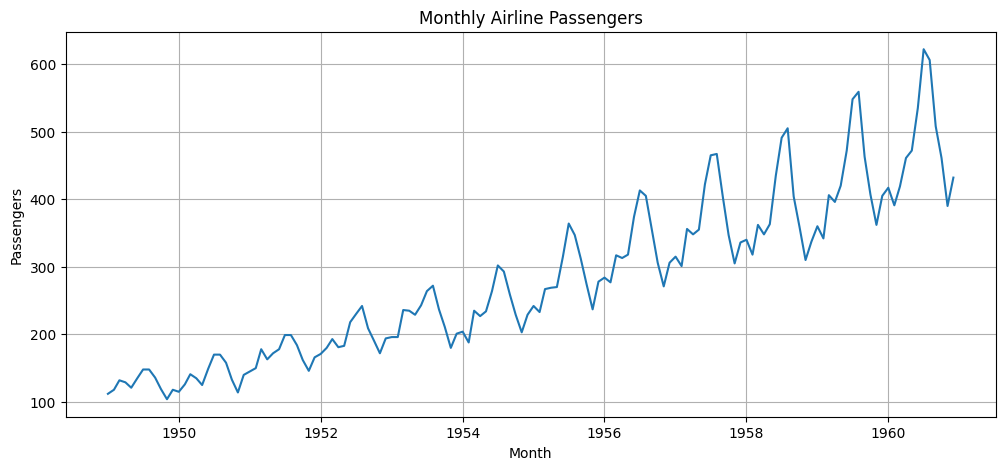

In [5]:
plt.figure(figsize=(12, 5))
plt.plot(df["Month"], df["Passengers"])
plt.title("Monthly Airline Passengers")
plt.xlabel("Month")
plt.ylabel("Passengers")
plt.grid(True)
plt.show()


### **Create Time Features for EDA:**

In [6]:
df["Year"] = df["Month"].dt.year
df["Month_num"] = df["Month"].dt.month
df.head()


,Month,Passengers,Year,Month_num
0,1949-01-01,112,1949,1
1,1949-02-01,118,1949,2
2,1949-03-01,132,1949,3
3,1949-04-01,129,1949,4
4,1949-05-01,121,1949,5


### **Yearly Summary:**

In [7]:
print(df.groupby("Year")["Passengers"].mean())


Year
1949    126.666667
1950    139.666667
1951    170.166667
1952    197.000000
1953    225.000000
1954    238.916667
1955    284.000000
1956    328.250000
1957    368.416667
1958    381.000000
1959    428.333333
1960    476.166667
Name: Passengers, dtype: float64


### **Scale the Target Series:**

In [8]:
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_values = scaler.fit_transform(df[["Passengers"]])
scaled_values[:5]


array([[0.01544402],
       [0.02702703],
       [0.05405405],
       [0.04826255],
       [0.03281853]])

### **Define Sequence Builder:**

In [9]:
def create_sequences(data, look_back=12):
    X, y = [], []
    for i in range(len(data) - look_back):
        X.append(data[i:i+look_back, 0])
        y.append(data[i+look_back, 0])
    return np.array(X), np.array(y)
    

### **Define Hyperparameter Search Space:**

In [10]:
search_space = [
    {"look_back": 12, "units_1": 64, "units_2": 32, "dropout": 0.2, "batch_size": 16},
    {"look_back": 12, "units_1": 64, "units_2": 16, "dropout": 0.2, "batch_size": 16},
    {"look_back": 24, "units_1": 64, "units_2": 32, "dropout": 0.3, "batch_size": 16}
]
search_space


[{'look_back': 12,
  'units_1': 64,
  'units_2': 32,
  'dropout': 0.2,
  'batch_size': 16},
 {'look_back': 12,
  'units_1': 64,
  'units_2': 16,
  'dropout': 0.2,
  'batch_size': 16},
 {'look_back': 24,
  'units_1': 64,
  'units_2': 32,
  'dropout': 0.3,
  'batch_size': 16}]

### **Define Model Builder:**

In [11]:
def build_airline_lstm(input_shape, units_1=64, units_2=32, dropout=0.2):
    model = Sequential([
        Input(shape=input_shape),
        LSTM(units_1, return_sequences=True),
        Dropout(dropout),
        LSTM(units_2),
        Dense(16, activation="relu"),
        Dense(1)
    ])
    model.compile(optimizer="adam", loss="mse")
    return model
    

### **Manual Hyperparameter Tuning Loop:**

In [12]:
best_config = None
best_val_rmse = np.inf
best_artifacts = None


### **Run Hyperparameter Tuning:**

In [13]:
for config in search_space:
    look_back = config["look_back"]
    X_all, y_all = create_sequences(scaled_values, look_back=look_back)
    X_all = X_all.reshape((X_all.shape[0], X_all.shape[1], 1))

    split_index = int(len(X_all) * 0.8)
    X_train, X_val = X_all[:split_index], X_all[split_index:]
    y_train, y_val = y_all[:split_index], y_all[split_index:]

    temp_model = build_airline_lstm(
        input_shape=(look_back, 1),
        units_1=config["units_1"],
        units_2=config["units_2"],
        dropout=config["dropout"]
    )

    temp_model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=15,
        batch_size=config["batch_size"],
        verbose=0
    )

    val_pred = temp_model.predict(X_val, verbose=0)
    val_rmse = np.sqrt(mean_squared_error(y_val, val_pred))
    print(config, "-> Validation RMSE:", round(val_rmse, 4))

    if val_rmse < best_val_rmse:
        best_val_rmse = val_rmse
        best_config = config
        best_artifacts = (X_all, y_all)

print("\nBest config:", best_config)
print("Best validation RMSE:", round(best_val_rmse, 4))


{'look_back': 12, 'units_1': 64, 'units_2': 32, 'dropout': 0.2, 'batch_size': 16} -> Validation RMSE: 0.145
{'look_back': 12, 'units_1': 64, 'units_2': 16, 'dropout': 0.2, 'batch_size': 16} -> Validation RMSE: 0.1425
{'look_back': 24, 'units_1': 64, 'units_2': 32, 'dropout': 0.3, 'batch_size': 16} -> Validation RMSE: 0.1422

Best config: {'look_back': 24, 'units_1': 64, 'units_2': 32, 'dropout': 0.3, 'batch_size': 16}
Best validation RMSE: 0.1422


### **Prepare Final Sequence Data:**

In [14]:
look_back = best_config["look_back"]
X_all, y_all = create_sequences(scaled_values, look_back=look_back)
X_all = X_all.reshape((X_all.shape[0], X_all.shape[1], 1))

split_index = int(len(X_all) * 0.8)
X_train, X_test = X_all[:split_index], X_all[split_index:]
y_train, y_test = y_all[:split_index], y_all[split_index:]

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)


X_train: (96, 24, 1)
X_test : (24, 24, 1)


### **Build Final Model:**

In [15]:
model = build_airline_lstm(
    input_shape=(look_back, 1),
    units_1=best_config["units_1"],
    units_2=best_config["units_2"],
    dropout=best_config["dropout"]
)
model.summary()


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm_6 (LSTM)                        │ (None, 24, 64)              │          16,896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 24, 64)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_7 (LSTM)                        │ (None, 32)                  │          12,416 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_6 (Dense)                      │ (None, 16)                  │             528 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_7 (Dense)                      │ (None, 1)                   │              17 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 29,857 (116.63 KB)

 Trainable params: 29,857 (116.63 KB)

 Non-trainable params: 0 (0.00 B)

### **Configure Callbacks:**

In [16]:
early_stopping = EarlyStopping(monitor="val_loss", patience=6, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3, min_lr=1e-6)
print("Callbacks configured successfully.")


Callbacks configured successfully.


### **Train Final Model:**

In [17]:
history = model.fit(
    X_train,
    y_train,
    validation_data=(X_test, y_test),
    epochs=50,
    batch_size=best_config["batch_size"],
    callbacks=[early_stopping, reduce_lr],
    verbose=1
)


Epoch 1/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 64ms/step - loss: 0.0728 - val_loss: 0.0831 - learning_rate: 0.0010
Epoch 2/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0163 - val_loss: 0.0245 - learning_rate: 0.0010
Epoch 3/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0104 - val_loss: 0.0468 - learning_rate: 0.0010
Epoch 4/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0125 - val_loss: 0.0408 - learning_rate: 0.0010
Epoch 5/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0076 - val_loss: 0.0204 - learning_rate: 0.0010
Epoch 6/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0095 - val_loss: 0.0245 - learning_rate: 0.0010
Epoch 7/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0075 - val_loss: 0.0259 - learning_rate: 0.0010
Epoch 8/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0082 - val_loss: 0.0226 - learning_rate: 0.0010
Epoch 9/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0072 - val_loss: 0.0214 - learning_rate: 5.0000e-04
Epoch 10/50
6/6 ━━━━━━━━━━━━━━━━━

### **Plot Loss Curves:**

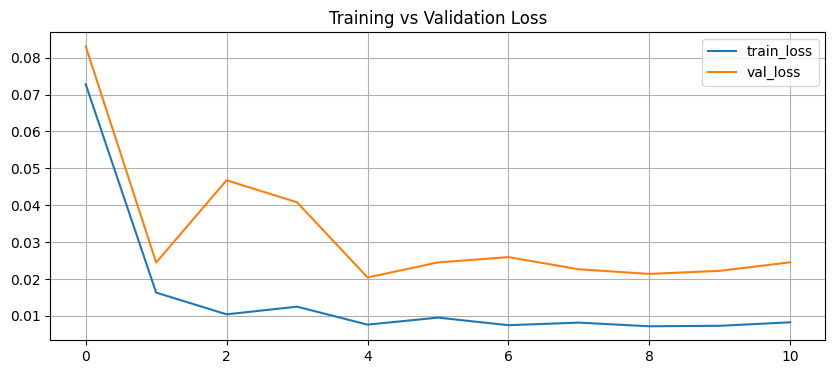

In [18]:
plt.figure(figsize=(10, 4))
plt.plot(history.history["loss"], label="train_loss")
plt.plot(history.history["val_loss"], label="val_loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.grid(True)
plt.show()


### **Predict on Train and Test:**

In [19]:
train_pred = model.predict(X_train, verbose=0)
test_pred = model.predict(X_test, verbose=0)


### **Inverse Transform Predictions:**

In [20]:
train_pred_inv = scaler.inverse_transform(train_pred)
test_pred_inv = scaler.inverse_transform(test_pred)
y_train_inv = scaler.inverse_transform(y_train.reshape(-1, 1))
y_test_inv = scaler.inverse_transform(y_test.reshape(-1, 1))


### **Evaluate Metrics:**

In [21]:
rmse = np.sqrt(mean_squared_error(y_test_inv, test_pred_inv))
mae = mean_absolute_error(y_test_inv, test_pred_inv)
r2 = r2_score(y_test_inv, test_pred_inv)

print("Test RMSE:", round(rmse, 4))
print("Test MAE :", round(mae, 4))
print("Test R2  :", round(r2, 4))


Test RMSE: 74.0126
Test MAE : 59.5008
Test R2  : 0.0177


### **Plot Actual vs Predicted on Test:**

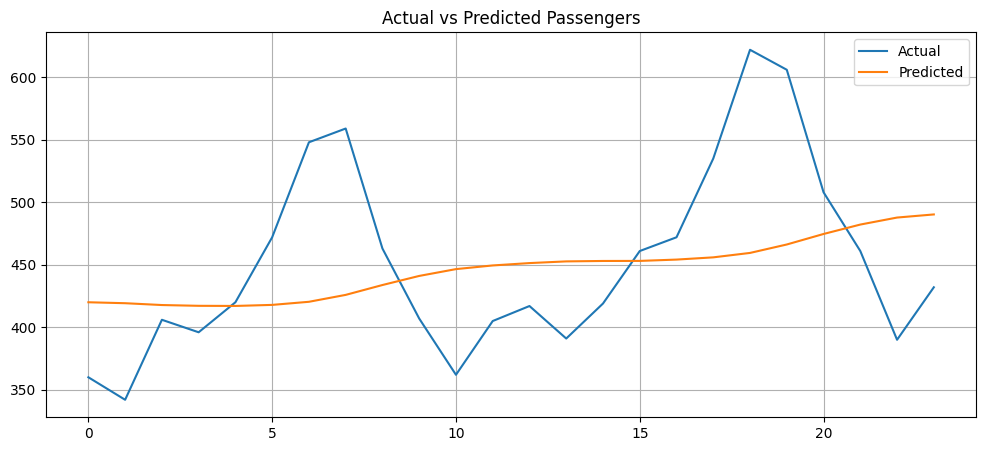

In [22]:
plt.figure(figsize=(12, 5))
plt.plot(y_test_inv, label="Actual")
plt.plot(test_pred_inv, label="Predicted")
plt.title("Actual vs Predicted Passengers")
plt.legend()
plt.grid(True)
plt.show()


### **Prepare Future Forecast Function:**

In [23]:
def forecast_future(model, recent_data, n_steps, scaler_obj):
    forecast = []
    current_seq = recent_data.copy()
    for _ in range(n_steps):
        pred = model.predict(current_seq.reshape(1, current_seq.shape[0], 1), verbose=0)[0][0]
        forecast.append(pred)
        current_seq = np.append(current_seq[1:], pred)
    return scaler_obj.inverse_transform(np.array(forecast).reshape(-1, 1))


### **Forecast Next 12 Months:**

In [24]:
recent_seq = scaled_values[-look_back:, 0]
future_forecast = forecast_future(model, recent_seq, n_steps=12, scaler_obj=scaler)
future_forecast.flatten()


array([491.3811 , 492.7729 , 494.31735, 495.59827, 496.96857, 498.25433,
       499.34543, 500.17114, 501.0515 , 502.41495, 503.98883, 505.6803 ],
      dtype=float32)

### **Build Future Date Index:**

In [25]:
last_date = df["Month"].iloc[-1]
future_dates = pd.date_range(start=last_date + pd.offsets.MonthBegin(1), periods=12, freq="MS")
forecast_df = pd.DataFrame({"Month": future_dates, "Forecasted_Passengers": future_forecast.flatten()})
forecast_df.head()


,Month,Forecasted_Passengers
0,1961-01-01,491.381104
1,1961-02-01,492.772888
2,1961-03-01,494.317352
3,1961-04-01,495.598267
4,1961-05-01,496.968567


### **Plot Historical + Forecast:**

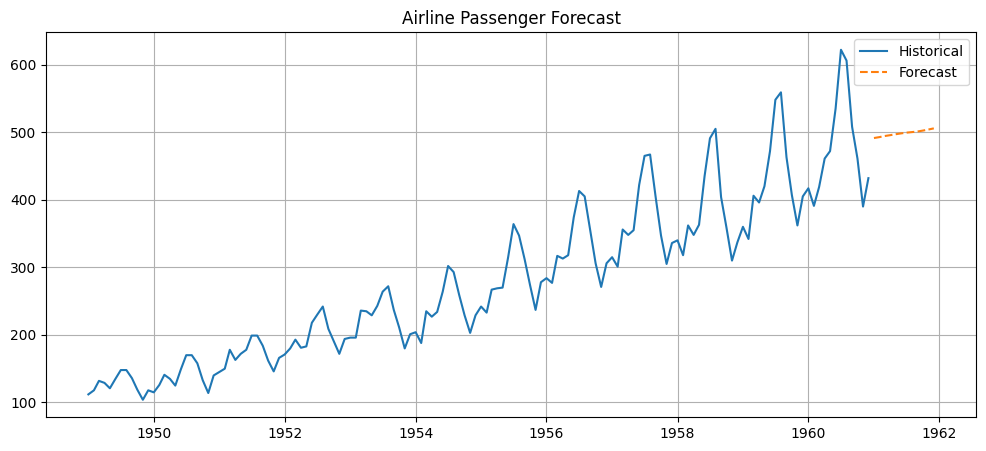

In [26]:
plt.figure(figsize=(12, 5))
plt.plot(df["Month"], df["Passengers"], label="Historical")
plt.plot(forecast_df["Month"], forecast_df["Forecasted_Passengers"], label="Forecast", linestyle="--")
plt.title("Airline Passenger Forecast")
plt.legend()
plt.grid(True)
plt.show()


### **Save Model and Artifacts:**

In [27]:
model.save("airline_passenger_lstm.h5")
with open("airline_passenger_scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)
with open("airline_passenger_best_config.pkl", "wb") as f:
    pickle.dump(best_config, f)
print("Model and artifacts saved successfully.")


Model and artifacts saved successfully.


### **Reload Saved Artifacts:**

In [28]:
from tensorflow.keras.models import load_model
import pickle

reloaded_model = load_model("airline_passenger_lstm.h5", compile=False)

with open("airline_passenger_scaler.pkl", "rb") as f:
    scaler_loaded = pickle.load(f)

with open("airline_passenger_best_config.pkl", "rb") as f:
    config_loaded = pickle.load(f)

print("Reloaded artifacts successfully.")

Reloaded artifacts successfully.


### **Forecast with Reloaded Model:**

In [29]:
recent_seq = scaled_values[-config_loaded["look_back"]:, 0]
future_forecast_reload = forecast_future(reloaded_model, recent_seq, 6, scaler_loaded)
print(future_forecast_reload.flatten())


[491.3811  492.7729  494.31735 495.59827 496.96857 498.25433]


### **Project Summary**

This project presents a complete implementation of an **Airline Passenger Forecasting System using LSTM Neural Networks**, focusing on predicting future passenger demand.

The workflow begins with preprocessing time-series data, including normalization and sequence preparation.

The core of the system is an **LSTM-based Deep Learning Model**, which consists of:

### **1. Sequence Input Layer**

- Converts time-series data into sequences  

### **2. LSTM Layers**

- Capture long-term dependencies  
- Learn temporal relationships  

### **3. Dense Output Layer**

- Predicts future passenger values  

The model learns:
- seasonality patterns  
- long-term trends  
- temporal dependencies  

A key strength of this project is:

- **Temporal modeling capability**
  - handles sequential data effectively  

- **Business relevance**
  - supports decision-making  

Evaluation is performed using:

- Mean Squared Error (MSE)  
- Root Mean Squared Error (RMSE)  

The system can be used in real-world applications to:

- forecast demand  
- optimize pricing strategies  
- improve operational planning  

Overall, this project demonstrates strong AI capabilities and showcases the ability to build **time-series forecasting systems using deep learning**.

## **Key Highlights**

- Built an **Airline Passenger Forecasting system using LSTM**, targeting time-series applications.

- Addressed practical business problem:
  - forecasting passenger demand  

- Utilized dataset with:
  - historical time-series data  

- Implemented a complete **data preprocessing pipeline**, including:
  - normalization  
  - sequence generation  

- Leveraged **LSTM neural networks**, enabling:
  - modeling of temporal dependencies  

- Designed a **forecasting system**, enabling:
  - prediction of future values  

- Developed a **time-series model**, capable of:
  - capturing trends and seasonality  

- Evaluated model performance using:
  - MSE, RMSE  

- Enabled **real-world applications**, including:
  - demand forecasting  
  - revenue optimization  
  - capacity planning  

- Designed for **deployment scenarios**, including:
  - forecasting dashboards  
  - decision-support systems  

- Demonstrates strong expertise in:
  - **time-series forecasting**  
  - **deep learning (LSTM)**  
  - **data-driven decision-making**